#**Synapse Week One**

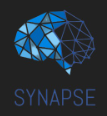

Last week, we focused on building the foundations needed to get started with Machine Learning. We explored Python and learned how to work with and understand data through Exploratory Data Analysis (EDA).

Now, it is time to take the next step and use that knowledge to build our first Machine Learning model. In this task, we will explore Regression, a type of supervised learning where the goal is to predict a continuous numerical value.

We will begin by exploring an insurance dataset and using EDA to understand the relationships between its different attributes and the insurance charges. Once we understand our data, we will prepare it for Machine Learning and build a Linear Regression model to predict the incurred charges.

But we won't stop at simply using a library. We will also take a look under the hood and implement Linear Regression from scratch, giving us a better understanding of what happens when a model is trained.

Resources and comments are provided throughout the notebook. Go through them carefully, understand the concepts, and then get coding.

Let's get started.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

https://www.geeksforgeeks.org/ml-classification-vs-regression/
(Short and Sweet)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [ ]:
%pip install shap -q  #Will be used later on

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Regression

For regression we will use insurance dataset, which contains medical costs incurred
https://drive.google.com/file/d/1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ/view?usp=sharing

## Basic EDA

### Import dataset

In [6]:
df=pd.read_csv('https://drive.google.com/uc?export=download&id=1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ')

### Use the very first steps involved in EDA -> info, head and describe

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

### Now, plot a histogram to understand insurance charges *distribution*

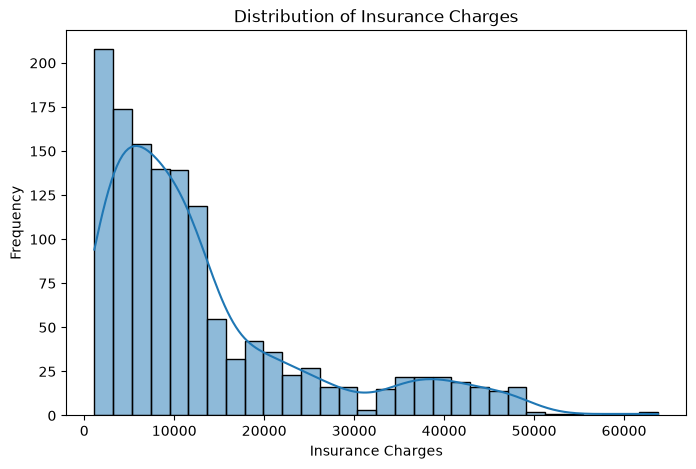

In [7]:
plt.figure(figsize=(8, 5))
sb.histplot(df["charges"], kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")
plt.show()


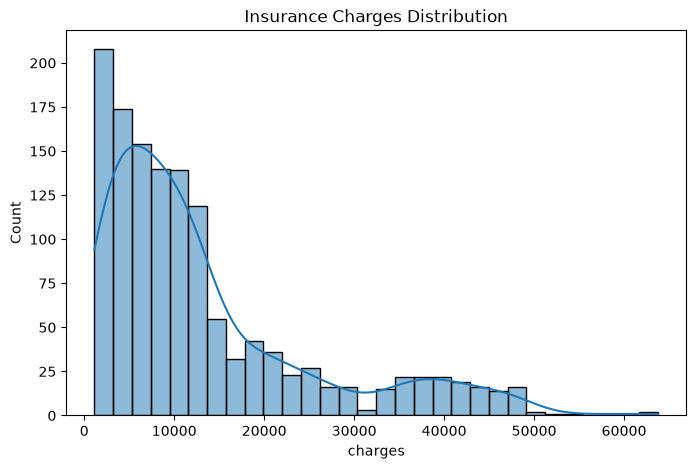

In [8]:
plt.figure(figsize=(8, 5))
sb.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()


### Plot a scatter plot between age and insurance charges

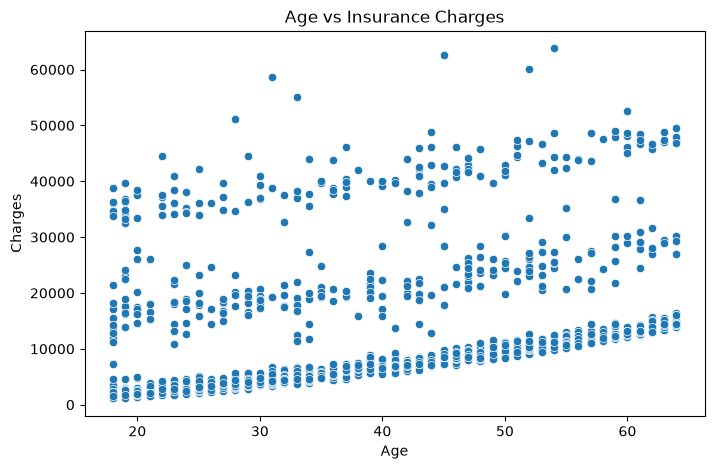

In [9]:
plt.figure(figsize=(8, 5))
sb.scatterplot(x=df["age"], y=df["charges"])
plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()


### Similarly, plot scatterplots for no. of children and charges, and also for bmi and charges


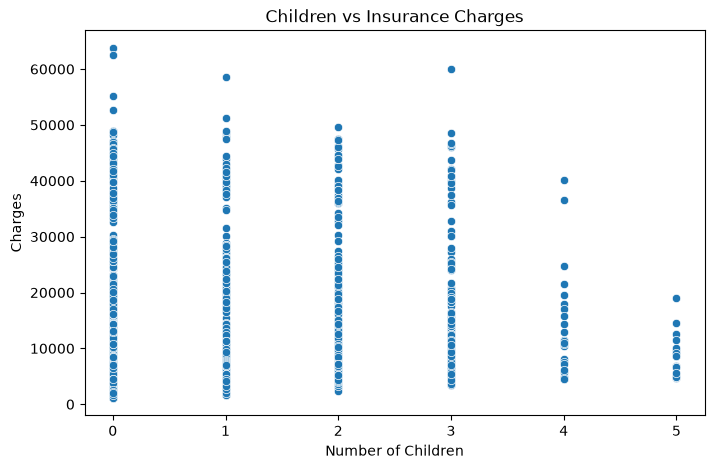

In [10]:
plt.figure(figsize=(8, 5))
sb.scatterplot(x=df["children"], y=df["charges"])
plt.title("Children vs Insurance Charges")
plt.xlabel("Number of Children")
plt.ylabel("Charges")
plt.show()


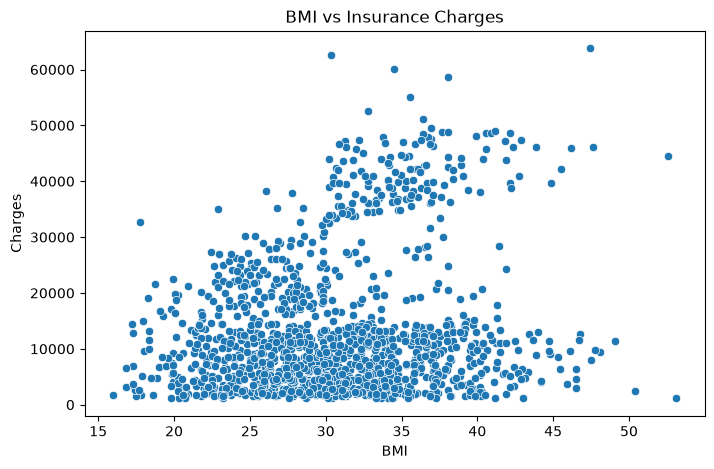

In [11]:
plt.figure(figsize=(8, 5))
sb.scatterplot(x=df["bmi"], y=df["charges"])
plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()


### Now, use boxplots to find correlation between Sex and Charges, between Smoker and charges, and also between region and charges

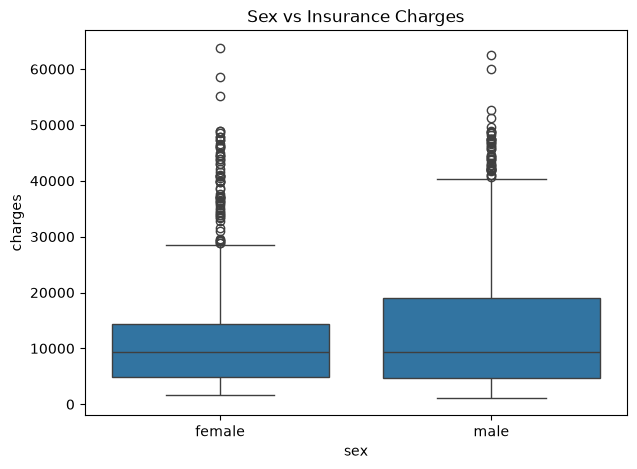

In [12]:
plt.figure(figsize=(7, 5))
sb.boxplot(x=df["sex"], y=df["charges"])
plt.title("Sex vs Insurance Charges")
plt.show()


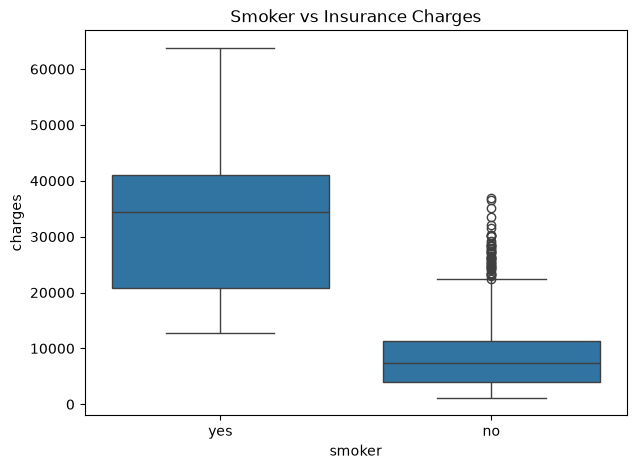

In [13]:
plt.figure(figsize=(7, 5))
sb.boxplot(x=df["smoker"], y=df["charges"])
plt.title("Smoker vs Insurance Charges")
plt.show()


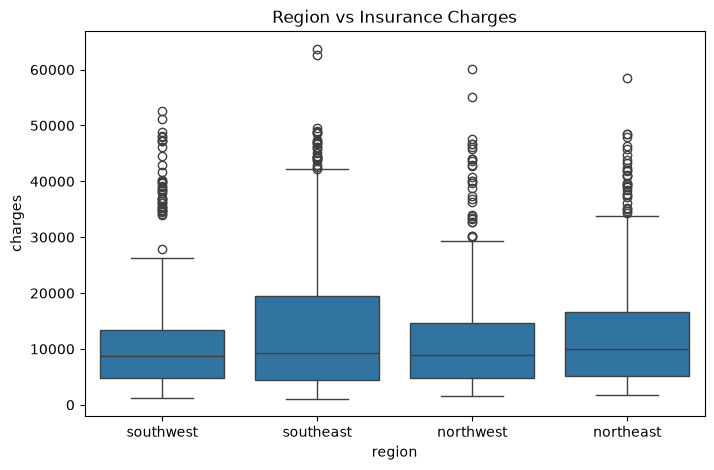

In [14]:
plt.figure(figsize=(8, 5))
sb.boxplot(x=df["region"], y=df["charges"])
plt.title("Region vs Insurance Charges")
plt.show()


##### Now, make a heatmap to understand correlation between all attributes

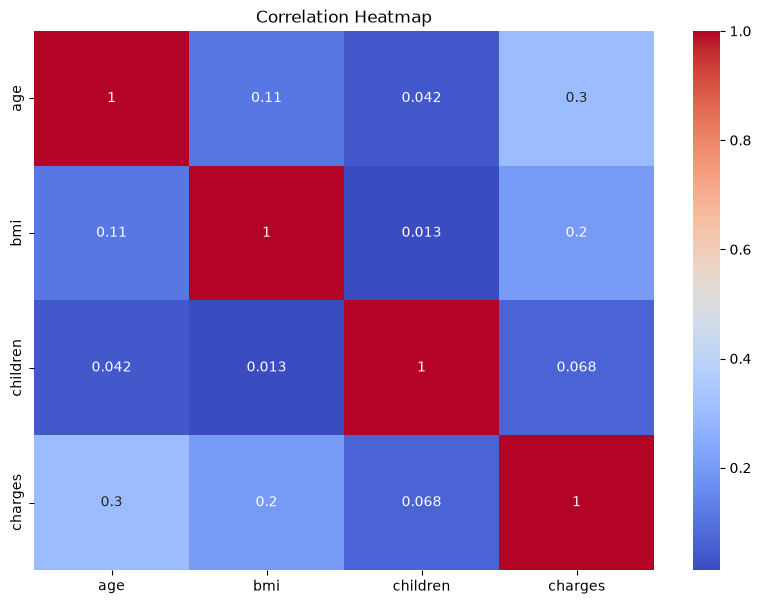

In [15]:
plt.figure(figsize=(10, 7))
sb.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Question: What do you infer from the above analysis🤔

### Answer here:

From the EDA, I understood that age, BMI and especially smoking status can affect insurance charges. Smoker status shows a strong difference in charges. Age also has a positive relationship with charges. The number of children has a much weaker relationship. The boxplots help compare charges across categories, while the heatmap shows relationships between numerical variables.


### Now let's prep our data to perform Regression to predict the Incurred Charges

### Again do df.info() see how the datatype is

In [16]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


### As you can see, sex, region and smoker attributes are of the object data type.
### So, convert them into numerical labels, using Label Encoder

from sklearn.preprocessing import LabelEncoder

# Make a copy so the original dataframe remains available for reference
df_encoded = df.copy()

# Create one LabelEncoder and encode each categorical column
le = LabelEncoder()
categorical_columns = ["sex", "smoker", "region"]

for col in categorical_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df = df_encoded


In [17]:
print("Label encoding completed.")
df.head()


Label encoding completed.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


Do df.head() to see how your dataframe looks like after LabelEncoding

In [19]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Question: What does label encoder do? 🤔

### Now that you already know about standardization and normalization (I hope🙃), implement normalization here here:


##### Import MinMaxScaler from sklearn and normalize the coloums - ['age','bmi', 'children', 'charges']

### Answer:

Normalization changes the values of a column to a common range, usually from 0 to 1. Here we normalize the numerical columns so that variables with different scales can be handled more consistently by the model.


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["sex", "smoker", "region"]:
    df[col] = le.fit_transform(df[col])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,0,0.321227,0.0,1,3,0.251611
1,0.000000,1,0.479150,0.2,0,2,0.009636
2,0.217391,1,0.458434,0.6,0,2,0.053115
3,0.326087,1,0.181464,0.0,0,1,0.333010
4,0.304348,1,0.347592,0.0,0,1,0.043816


## Question: Why standardization is not needed here? 🤔



### Answer:

Standardization is not needed here because the task specifically asks us to use MinMaxScaler for normalization. MinMaxScaler already brings the selected columns into the same 0 to 1 range, so applying standardization as well would be unnecessary.


As we are going to predict Insurance Charges, let us make two sections: one containing only the 'charges', and the other containing all values except for 'charges'

In [22]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1338, 6)
y shape: (1338,)


### Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

### Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [24]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (936, 6)
X_test : (402, 6)
y_train: (936,)
y_test : (402,)


### The data is now split into 2 datasets of size 70% and 30% of original dataset. Surprised? 😮

### We have preprocessed our DataFrame now we'll perform Regression on this Data

### First lets understand Linear Regression, watch this video carefully it will be helpfull later on :)

https://www.youtube.com/watch?v=7ArmBVF2dCs

### A quick article
https://www.analyticsvidhya.com/blog/2021/08/understanding-linear-regression-with-mathematical-insights/

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

regressor = LinearRegression()


In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
le = LabelEncoder()

for col in ["sex", "smoker", "region"]:
    df[col] = le.fit_transform(df[col])

# Create X and y again
X = df.drop("charges", axis=1)
y = df["charges"]

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Check
print(X_train.head())
print(X_train.dtypes)

          age  sex       bmi  children  smoker  region
332  0.934783    0  0.408932       0.0       0       1
355  0.608696    1  0.313156       0.0       0       3
138  0.782609    0  0.428840       0.6       0       2
381  0.804348    1  0.396153       0.0       1       0
292  0.152174    1  0.795803       0.4       1       2
age         float64
sex           int64
bmi         float64
children    float64
smoker        int64
region        int64
dtype: object


In [32]:
regressor.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.19, 0. , 0.2 , 0.03, 0.38,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.05232
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


#### The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

#### Use regressor.predict() on X_test and store it in a variable called "y_pred". Print type and size of the y_pred.

#### Size should be 402 if everything is correct. Yeh line confirm karna hai

In [33]:
y_pred = regressor.predict(X_test)

print("Type of y_pred:", type(y_pred))
print("Size of y_pred:", y_pred.size)


Type of y_pred: <class 'numpy.ndarray'>
Size of y_pred: 402


In [34]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 0.0086132059969997


### Visualize the predictions, plot a scatter plot of y_test vs y_pred and also plot the best fit line

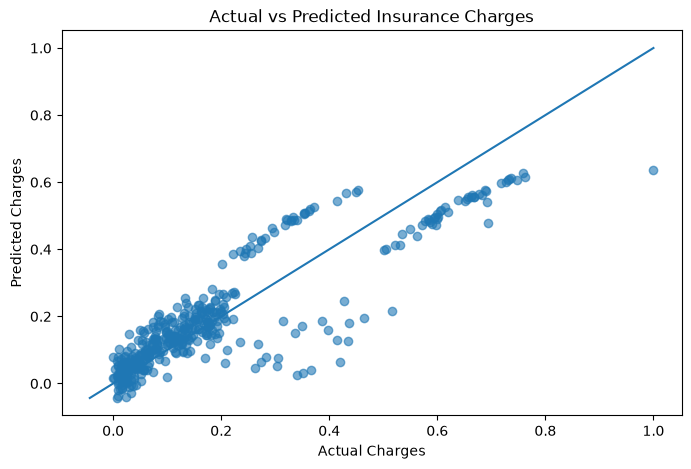

In [35]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)

# Best-fit/reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum])

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()


# Now let's start the fun part 😃

### Have you ever wondered what happens when you call **'regressor.fit(X_train, y_train)'** ?

### To understand what's hapenning in .fit method we will be implementing Linear Regression from scratch.

In [36]:
class LinearRegression():

    def __init__(self, learning_rate, iterations):
        # initialize the learning rate and iterations provided by the user
        self.learning_rate = learning_rate
        self.iterations = iterations

    # Function for model training
    def fit(self, X, Y):

        # no_of_training_examples, no_of_features
        self.m, self.n = X.shape

        # self.m represents the number of rows (samples)
        # self.n represents the number of features/columns

        # weight initialization
        self.W = np.zeros(self.n)

        # bias initialization
        self.b = 0

        self.X = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
        self.Y = Y.to_numpy() if hasattr(Y, "to_numpy") else np.asarray(Y)

        # gradient descent learning
        for i in range(self.iterations):
            self.update_weights()

        return self

    # Helper function to update weights in gradient descent
    def update_weights(self):

        Y_pred = self.X.dot(self.W) + self.b

        # calculate gradients
        dW = (-2 / self.m) * self.X.T.dot(self.Y - Y_pred)
        db = (-2 / self.m) * np.sum(self.Y - Y_pred)

        # update the weights
        self.W = self.W - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db

        return self

    def predict(self, X):

        X = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
        return X.dot(self.W) + self.b


In [ ]:
model = LinearRegression( iterations = 10000, learning_rate = 0.0015 )

model.fit(X_train, y_train)

## Question: What is this function actually doing? 🤔
#### Answer Here

The `fit()` function trains our Linear Regression model using gradient descent. It first finds the number of training rows and features, starts the weights and bias at zero, and then repeatedly updates them. In every iteration, it calculates the prediction, finds how much the prediction is wrong, calculates the gradients, and changes the weights and bias to reduce the error.


### Now predict the output for the test data

In [38]:
model = LinearRegression(iterations=10000, learning_rate=0.0015)
model.fit(X_train, y_train)

In [39]:
y_pred_scratch = model.predict(X_test)

print("Type of y_pred:", type(y_pred_scratch))
print("Size of y_pred:", y_pred_scratch.size)


Type of y_pred: <class 'numpy.ndarray'>
Size of y_pred: 402


### Calculate the mean squared error


In [40]:
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
print("Mean Squared Error:", mse_scratch)


Mean Squared Error: 0.008786906117368229


### Plot a similar scatter plot as above


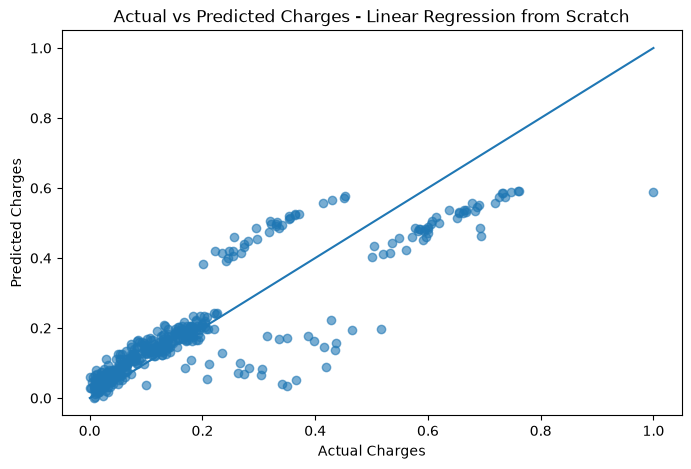

In [41]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_scratch, alpha=0.6)

minimum = min(y_test.min(), y_pred_scratch.min())
maximum = max(y_test.max(), y_pred_scratch.max())
plt.plot([minimum, maximum], [minimum, maximum])

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges - Linear Regression from Scratch")
plt.show()


How to Approach the Research Tasks :)

Guys, one important point about how you should approach these tasks.

The links and videos provided are meant to be read/watched. Go through them, understand the concepts, and then write what you understood in your own words. You can also find your own resources — don't restrict yourself to the links we provide.

And please, don’t just GPT your way through the tasks. These are your foundational basics, so actually understand what you're doing. Try reading documentation, Stack Overflow discussions, technical articles, etc. These will become your best guides when you're learning ML independently.

The Research Task is compulsory and one of the most important parts of your learning, irrespective of what you do. Research is an engineer's way of learning — it's how you learn ML for what it actually is, rather than just learning how to write the code.

For the Research Task, research properly, understand what you find, and explain it in your own words. No implementation is required unless mentioned.

The best Research Task submission after every task will be featured on Synapse's LinkedIn with a tag, giving you an opportunity to connect with our alumni and seniors and grow your network.

So don't treat the Research Task as just another question to finish. Actually explore, understand, and learn from it :)


## Research Task: Underfitting & Overfitting

### What I understood

**Underfitting:**  
Underfitting happens when a model is too simple to learn the important patterns in the training data. Because it has not learned enough, it performs poorly on both the training data and unseen test data. It is usually connected with **high bias and low variance**.

**Overfitting:**  
Overfitting happens when a model learns the training data too closely, including noise and small details that do not generalize. The model can perform very well on training data but much worse on new test data. It is usually connected with **low bias and high variance**.

**Bias and variance:**  
Bias is the error caused by making the model too simple or by making strong assumptions about the data. High bias usually leads to underfitting. Variance describes how much the model's predictions change when the training data changes. High variance usually leads to overfitting.

**How to identify them:**  
- If training performance is poor and test performance is also poor, the model may be underfitting.
- If training performance is very good but test performance is much worse, the model may be overfitting.
- Comparing training and validation/test performance is therefore useful for identifying the problem.

**How to deal with them:**  
- For **underfitting**, we can use a more suitable/complex model, add useful features, or reduce excessive regularization.
- For **overfitting**, we can simplify the model, use regularization, collect more training data, or use techniques such as cross-validation.

The main idea I understood is that we want a model that learns the useful pattern in the data without being too simple or simply memorizing the training data.


End of Task

©DJS Synapse 2026 - 2027